## 1. Setup and Library Imports

Brings in the Regression/Classification model families used across this notebook - scikit-learn's **RandomForestRegressor**, XGBoost's **XGBRegressor**/**XGBClassifier** and PyTorch for the LSTM, along with evaluation metrics need for both the Regression task (MSE, MAE, R²) and the Classification task (Accuracy, Precision, Recall, ROC-AUC)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

---
## 2. Loading the Dataset

Loads the three artifacts exported at the end of the Feature Engineering notebook:
- **train_data.csv** : full training set with all engineered features and **RUL_capped** target.
- **test_features.csv** : engineered features for the (truncated) test engines - no RUL label included, since this mimics a real deployment scenario.
- **test_rul.csv** : the true **RUL_capped**  for each test engine at the point the trajectory was cut off, used only for evaluation.

In [3]:
train = pd.read_csv('data/transform/train_data.csv')
train = train.sort_values(['engine_id','cycle_count']).reset_index(drop=True)
train.head()

,engine_id,cycle,sensor_2_norm,sensor_3_norm,sensor_4_norm,sensor_7_norm,sensor_8_norm,sensor_9_norm,sensor_11_norm,sensor_12_norm,...,sensor_9_norm_absdev,sensor_11_norm_absdev,sensor_12_norm_absdev,sensor_13_norm_absdev,sensor_14_norm_absdev,sensor_15_norm_absdev,sensor_17_norm_absdev,sensor_20_norm_absdev,sensor_21_norm_absdev,RUL_capped
0,1,1,0.183735,0.406802,0.309757,0.726248,0.242424,0.109755,0.369048,0.633262,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,125
1,1,2,0.283133,0.453019,0.352633,0.628019,0.212121,0.100242,0.380952,0.765458,...,0.009513,0.011905,0.132196,0.073529,0.036794,0.047326,0.000000,0.046512,0.006352,125
2,1,3,0.343373,0.369523,0.370527,0.710145,0.272727,0.140043,0.250000,0.795309,...,0.030288,0.119048,0.162047,0.014706,0.027815,0.006541,0.166667,0.085271,0.103286,125
3,1,4,0.343373,0.256159,0.331195,0.740741,0.318182,0.124518,0.166667,0.889126,...,0.014763,0.202381,0.255864,0.088235,0.024719,0.197384,0.000000,0.139535,0.062276,125
4,1,5,0.349398,0.257467,0.404625,0.668277,0.242424,0.149960,0.255952,0.746269,...,0.040205,0.113095,0.113006,0.029412,0.024874,0.038092,0.083333,0.124031,0.020160,125


In [4]:
test = pd.read_csv('data/transform/test_features.csv')
test = test.sort_values(['engine_id','cycle_count']).reset_index(drop=True)
test.head()

,engine_id,cycle,sensor_2_norm,sensor_3_norm,sensor_4_norm,sensor_7_norm,sensor_8_norm,sensor_9_norm,sensor_11_norm,sensor_12_norm,...,sensor_8_norm_absdev,sensor_9_norm_absdev,sensor_11_norm_absdev,sensor_12_norm_absdev,sensor_13_norm_absdev,sensor_14_norm_absdev,sensor_15_norm_absdev,sensor_17_norm_absdev,sensor_20_norm_absdev,sensor_21_norm_absdev
0,1,1,0.545181,0.310661,0.269413,0.652174,0.212121,0.127614,0.208333,0.646055,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,2,0.150602,0.379551,0.222316,0.805153,0.166667,0.146684,0.386905,0.739872,...,0.045455,0.019070,0.178571,0.093817,0.044118,0.072608,0.095806,0.083333,0.124031,0.024993
2,1,3,0.376506,0.346632,0.322248,0.685990,0.227273,0.158081,0.386905,0.699360,...,0.015152,0.030468,0.178571,0.053305,0.000000,0.023480,0.149673,0.083333,0.170543,0.059514
3,1,4,0.370482,0.285154,0.408001,0.679549,0.196970,0.105717,0.255952,0.573561,...,0.015152,0.021897,0.047619,0.072495,0.029412,0.037930,0.051943,0.083333,0.108527,0.000276
4,1,5,0.391566,0.352082,0.332039,0.694042,0.166667,0.102396,0.273810,0.737740,...,0.045455,0.025218,0.065476,0.091684,0.000000,0.020590,0.008080,0.166667,0.100775,0.054543


In [5]:
test_output = pd.read_csv('data/transform/test_rul.csv')

test_output.head()

,RUL,engine_id,RUL_capped
0,112,1,112
1,98,2,98
2,69,3,69
3,82,4,82
4,91,5,91


---
### 3. Feature & Target Scaling

Two scalers are fit here, each serving a different downstream model:
- **cycle_count_scaler (Min-Max)**: rescales the raw cycle index to [0, 1]. Tree-based models don't need this, but the LSTM benefits from inputs on a comparable scale.
- **rul_scaler (Standard)**: standardizes **RUL_capped** to zero mean / unit variance. Neural networks trained with MSE loss converge more reliably on a standardized target; the tree models below intentionally keep using the raw, unscaled **RUL_capped** since they're invariant to monotonic transformations of the target.

Both scalers are fit on the training set only and applied to test, avoiding any leakage of test-set statistics.

In [6]:
cycle_count_scaler = MinMaxScaler()

train['cycle_count_scaled'] = cycle_count_scaler.fit_transform(train[['cycle_count']])
test['cycle_count_scaled'] = cycle_count_scaler.transform(test[['cycle_count']])

In [7]:
rul_scaler = StandardScaler()

train['RUL_capped_scaled'] = rul_scaler.fit_transform(train[['RUL_capped']])
test_output['RUL_capped_scaled'] = rul_scaler.transform(test_output[['RUL_capped']])

### Random Forest Model

A Random Forest Regressor is used as the first baseline: an ensemble of decision trees that is robust to differences in feature scale, handles non-linear sensor-RUL relationships out of the box, and requires no architecture tuning to get a reasonable result. It's trained on every individual cycle in **train** (not just the final reading), then evaluated the way a real deployment would use it - predicting from the **last available cycle** of each test engine.


In [8]:
TREE_FEATURES = [c for c in train.columns if c not in ['engine_id', 'RUL_capped','cycle','RUL_capped_scaled','cycle_count_scaled','failure_30']]

tree_train = train.sample(frac=1, random_state=42)
X_train = tree_train[TREE_FEATURES].values
y_train = tree_train['RUL_capped'].values

In [9]:
rf_model = RandomForestRegressor()

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

The model is trained with default hyperparameters (100 trees) directly on row-level data - every cycle of every training engine is treated as an independent training example. Real deployment only observes engines up to the current moment, so evaluation below uses the **most recent cycle** of each test engine rather than its full history.

In [10]:
last_cycles = test.groupby('engine_id').tail(1)
last_cycles.head()

,engine_id,cycle,sensor_2_norm,sensor_3_norm,sensor_4_norm,sensor_7_norm,sensor_8_norm,sensor_9_norm,sensor_11_norm,sensor_12_norm,...,sensor_9_norm_absdev,sensor_11_norm_absdev,sensor_12_norm_absdev,sensor_13_norm_absdev,sensor_14_norm_absdev,sensor_15_norm_absdev,sensor_17_norm_absdev,sensor_20_norm_absdev,sensor_21_norm_absdev,cycle_count_scaled
30,1,31,0.412651,0.221932,0.281229,0.735910,0.272727,0.155569,0.226190,0.660981,...,0.027955,0.017857,0.014925,0.044118,0.023532,0.010773,0.083333,0.038760,0.025269,0.083102
79,2,49,0.403614,0.339002,0.482444,0.590982,0.303030,0.103383,0.488095,0.650320,...,0.020506,0.142857,0.025586,0.073529,0.013882,0.085417,0.083333,0.147287,0.180199,0.132964
205,3,126,0.503012,0.407892,0.618501,0.441224,0.393939,0.123530,0.613095,0.456290,...,0.019698,0.101190,0.292111,0.014706,0.001497,0.081185,0.250000,0.046512,0.030378,0.346260
311,4,106,0.472892,0.512099,0.415766,0.449275,0.348485,0.132684,0.476190,0.680171,...,0.012474,0.125000,0.021322,0.058824,0.010476,0.168911,0.166667,0.232558,0.086026,0.290859
409,5,98,0.319277,0.412034,0.626435,0.553945,0.303030,0.144755,0.363095,0.492537,...,0.010993,0.053571,0.255864,0.117647,0.026628,0.024625,0.000000,0.224806,0.027755,0.268698


In [11]:
X_test = last_cycles[TREE_FEATURES].values
y_pred = rf_model.predict(X_test)

y_pred

array([123.13, 118.91,  59.94,  80.97,  89.14, 100.01, 116.02,  80.35,
       118.02,  94.04,  77.17,  91.5 ,  78.56, 118.67, 115.21, 107.51,
        56.21,  33.03,  88.93,  11.57,  52.07, 124.64, 112.56,  21.13,
       121.24, 113.4 ,  87.9 ,  85.14,  94.68,  92.37,  15.82,  53.44,
       119.26,   4.01,   7.92,  41.48,  31.29,  49.47, 122.47,  35.61,
        34.74,  13.75,  53.63, 111.48,  68.03,  44.9 , 101.33, 105.4 ,
        13.7 , 108.25, 106.42,  27.74,  29.87, 119.55, 117.94,  28.14,
        98.34,  42.32, 103.1 , 113.85,  23.29,  50.46,  76.11,  33.81,
       116.17,  17.88, 105.75,  13.6 , 120.32,  95.46, 107.55,  65.35,
       118.17,  99.73,  99.61,   9.93,  25.48, 118.44,  82.14,  86.92,
         5.71,   7.19, 113.44,  63.  , 122.23,  84.44, 119.34, 117.42,
       112.7 ,  35.92,  37.16,  22.8 ,  58.61,  58.54, 105.72, 119.35,
        90.63,  87.51, 104.52,  17.09])

In [12]:
def eval_metrics(y_true, y_pred):
    print(f'R2 Score: {r2_score(y_true, y_pred)}')
    print(f'MAE: {mean_absolute_error(y_true, y_pred)}')
    print(f'MSE: {mean_squared_error(y_true, y_pred)}')

In [13]:
eval_metrics(test_output['RUL_capped'], y_pred)

R2 Score: 0.886803779265724
MAE: 10.0518
MSE: 181.778132


### Key Findings — Random Forest Baseline

- **R² = 0.887**, **MAE ≈ 10.05 cycles**, **MSE ≈ 181.8** on the 100 test engines.
- The model explains roughly 89% of the variance in RUL using only the last observed cycle per engine - a strong baseline given it has no notion of trajectory history.
- Errors of ~10 cycles are within the noise band identified during EDA, but there's no mechanism here for the model to use *how* a sensor got to its current value, only its current value - a limitation the sequence model later in this notebook is designed to address.

### XGBoost Model

XGBoost is tried next using the identical feature set, training rows, and last-cycle evaluation protocol as the Random Forest above, so the two are directly comparable. Gradient boosting sequentially corrects the errors of prior trees and often beats a plain Random Forest - but only if reasonably tuned.


In [14]:
xg_model = XGBRegressor()

xg_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [15]:
y_pred = xg_model.predict(X_test)
y_pred

array([125.16012  , 125.409805 ,  60.091248 ,  85.10588  ,  77.578705 ,
        95.84815  , 111.12858  ,  81.44204  , 116.50559  ,  96.619026 ,
        72.82515  ,  91.9      ,  95.28503  , 115.49985  , 113.81781  ,
        98.108635 ,  55.306572 ,  20.425634 ,  67.10604  ,  10.259045 ,
        65.25381  , 124.134766 , 118.17825  ,  18.554062 , 117.15574  ,
       121.61616  ,  86.91927  ,  88.57922  , 100.74349  , 102.92748  ,
        11.885588 ,  44.642006 , 127.385506 ,   2.2276385,  14.846365 ,
        45.96961  ,   9.502317 ,  52.22653  , 126.22231  ,  35.708237 ,
        19.624067 ,  16.545427 ,  67.54979  , 120.50213  ,  62.921593 ,
        50.579575 ,  97.14845  , 102.9601   ,  10.82099  , 116.08438  ,
       110.688255 ,  22.841228 ,  30.840607 , 122.28512  , 111.281296 ,
        29.196486 , 105.62821  ,  34.460255 , 106.2164   , 113.67551  ,
        21.921162 ,  53.50066  , 101.655716 ,  34.37226  , 117.95702  ,
        10.204144 , 102.24265  ,   6.6705136, 122.54623  ,  96.5

In [16]:
eval_metrics(test_output['RUL_capped'], y_pred)

R2 Score: 0.8703175783157349
MAE: 10.634343147277832
MSE: 208.25277709960938


### Key Findings — XGBoost vs. Random Forest

| Metric | Random Forest | XGBoost |
|---|---|---|
| R² | **0.887** | 0.870 |
| MAE | **10.05** | 10.63 |
| MSE | **181.8** | 208.3 |

With default hyperparameters, the Random Forest baseline slightly **outperforms** XGBoost here. XGBoost wasn't tuned (no `n_estimators`, `max_depth`, or `learning_rate` were set), so this isn't a verdict on the algorithm - it's a reminder that boosted trees need hyperparameter search to show their usual edge over bagged trees. Both models still share the same fundamental limitation: each prediction comes from a single row, with no access to the engine's degradation trajectory.


### LSTM Model

Both tree models judge an engine from a single snapshot. But the EDA showed degradation is a temporal process - sensors trend gradually before accelerating near failure - so a sequence model that consumes a *window* of recent cycles should capture information the row-level models structurally cannot. The remainder of this notebook builds a 2-layer LSTM in PyTorch that takes the last 30 cycles of normalized sensor and health-index features and predicts RUL directly from that trajectory.

**Steps**:
1. Convert each engine's trajectory into overlapping fixed-length sequences (training) and a single trailing window (test).
2. Wrap the sequences in a PyTorch **Dataset**/**DataLoader**.
3. Define and train a 2-layer LSTM regressor.
4. Evaluate on the original (unscaled) RUL using the standardization scaler fit earlier.


In [17]:
def create_sequences(df, seq_len, features, target):
    X, y = [], []

    for eid in df['engine_id'].unique():
        engine = df[df['engine_id'] == eid]

        data = engine[features].values
        rul = engine[target].values

        for i in range(len(engine) - seq_len):
            X.append(data[i:i+seq_len])
            y.append(rul[i+seq_len-1])
    
    return np.array(X), np.array(y)

### Sequence Construction Details

- **`SEQ_LEN = 30`**: each training example is a 30-cycle sliding window; the label is the (already-capped) RUL at the final cycle of that window. This matches the rolling-feature window size used during feature engineering.
- **`LSTM_FEATURES`**: every `_norm` column, plus `cycle_count_scaled` and `health_index` - i.e. only features that are already on a comparable [0, 1]-ish scale. Raw, unnormalized sensors and the engineered absolute/delta features in their native units are deliberately excluded to keep the LSTM's input scale stable.

### Building Test-Time Windows

Unlike training, where every overlapping window of an engine's history becomes a separate example, test-time inference only needs **one window per engine**: the most recent **SEQ_LEN** cycles available, since that's the only information a real deployment would have when asked "how much life is left in this engine right now?"


In [18]:
SEQ_LEN = 30
LSTM_FEATURES = [c for c in train.columns if c.endswith('norm') or c == 'cycle_count_scaled' or c == 'health_index']

X_train, y_train_scaled = create_sequences(train, SEQ_LEN, LSTM_FEATURES, 'RUL_capped_scaled')

In [19]:
def create_test_sequences(df, seq_len, features):
    X_test = []

    for eid in df['engine_id'].unique():
        engine = df[df['engine_id'] == eid]

        data = engine[features].values
        X_test.append(data[-seq_len:])
    
    return np.array(X_test, dtype=np.float32)

In [20]:
X_test = create_test_sequences(test, SEQ_LEN, LSTM_FEATURES)
y_test_scaled = np.array(test_output['RUL_capped_scaled'])

### Training Utilities

The next several cells assemble the supporting PyTorch machinery before training starts:
- **`evaluate_standard_scaler`**: inverse-transforms standardized predictions back to raw RUL cycles before computing MAE/MSE/RMSE/R², since the model itself only ever sees standardized targets.
- **`CMAPSSDataset`** / **`DataLoader`**: wraps the NumPy sequence arrays into PyTorch tensors and batches them (batch size 64, shuffled) for mini-batch gradient descent.
- **`LSTMRegressor`**: a 2-layer LSTM (hidden size 64, dropout 0.2 between layers) followed by a single linear layer that maps the final hidden state to one RUL value.
- **Loss & optimizer**: MSE loss with the Adam optimizer (`lr=0.001`).
- **`train_model`** / **`model_predictions`**: a manual training loop (20 epochs, printing the summed loss per epoch) and a no-grad inference helper.


In [21]:
def evaluate_standard_scaler(y_true_scaled, y_pred_scaled, scaler):
    y_true = scaler.inverse_transform(np.asarray(y_true_scaled).reshape(-1, 1)).flatten()
    y_pred = scaler.inverse_transform(np.asarray(y_pred_scaled).reshape(-1, 1)).flatten()

    metrics = {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

    return metrics

In [22]:
class CMAPSSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]
    
train_dataset_scaled = CMAPSSDataset(X_train, y_train_scaled)

In [23]:
train_loader_scaled = DataLoader(dataset=train_dataset_scaled, batch_size=64, shuffle=True)

In [24]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=64,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(64, 1)
    
    def forward(self, x):
        out, (hn, cn) = self.lstm(x)

        out = hn[-1]
        out = self.fc(out)

        return out.squeeze()

model = LSTMRegressor(len(LSTM_FEATURES))

In [25]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [26]:
def train_model(model, loader):
    for epoch in range(20):
        model.train()
        total_loss = 0

        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            preds = model(X_batch)

            loss = criterion(preds, y_batch)
            loss.backward()

            optimizer.step()

            total_loss += loss.item()
        
        print(epoch + 1, total_loss)

In [27]:
def model_predictions(model, X_test):
    model.eval()

    with torch.no_grad():
        y_pred = model(torch.tensor(X_test, dtype=torch.float32)).numpy()
    
    return y_pred

In [28]:
train_model(model, train_loader_scaled)

y_train_pred_scaled = model_predictions(model, X_train)
y_test_pred_scaled = model_predictions(model, X_test)

print("Training Data:")
print(evaluate_standard_scaler(y_train_scaled, y_train_pred_scaled, rul_scaler))
print()
print("Testing Data:")
print(evaluate_standard_scaler(y_test_scaled, y_test_pred_scaled, rul_scaler))

1 71.2684642598033
2 35.64841818809509
3 31.463472213596106
4 29.75213037058711
5 27.72672126069665
6 27.643885418772697
7 26.253156661987305
8 24.87372462451458
9 24.337426111102104
10 23.211104542016983
11 23.673360779881477
12 23.362931665033102
13 22.564824771136045
14 22.677965907379985
15 22.307216428220272
16 21.551410730928183
17 21.15917615033686
18 21.04001626558602
19 20.257166320458055
20 20.42183017730713
Training Data:
{'MAE': 7.410015705094146, 'MSE': 118.98470998520503, 'RMSE': np.float64(10.908011275443615), 'R2': 0.9308251613037302}

Testing Data:
{'MAE': 9.402662696838378, 'MSE': 160.7128165716074, 'RMSE': np.float64(12.677255877026676), 'R2': 0.8999214962806038}


### Key Findings — LSTM

Training loss drops steadily across the 20 epochs (71.3 → 35.6 → … → 20.4), indicating stable convergence with no divergence or instability.

| Split | MAE | RMSE | R² |
|---|---|---|---|
| Train | 7.41 | 10.91 | 0.931 |
| Test | 9.40 | 12.68 | 0.900 |

**This is the best-performing regressor so far**: R² = 0.90 on the held-out test engines beats both the Random Forest (0.887) and XGBoost (0.870), and the MAE of ~9.4 cycles is the lowest of the three. There is a visible train/test gap (0.931 vs 0.900) suggesting mild overfitting, but generalization is still clearly stronger than the row-level models - direct evidence that the trajectory information in the 30-cycle window carries real predictive signal beyond a single snapshot.


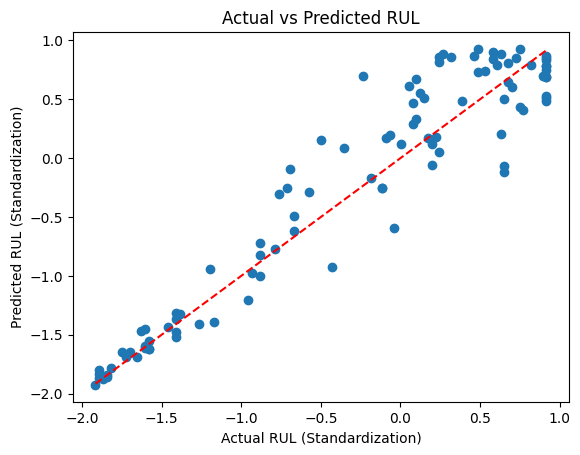

In [29]:
plt.scatter(y_test_scaled, y_test_pred_scaled)
plt.plot(
    [y_test_scaled.min(), y_test_scaled.max()],
    [y_test_scaled.min(), y_test_scaled.max()],
    'r--'
)
plt.title("Actual vs Predicted RUL")
plt.xlabel("Actual RUL (Standardization)")
plt.ylabel("Predicted RUL (Standardization)")
plt.show()

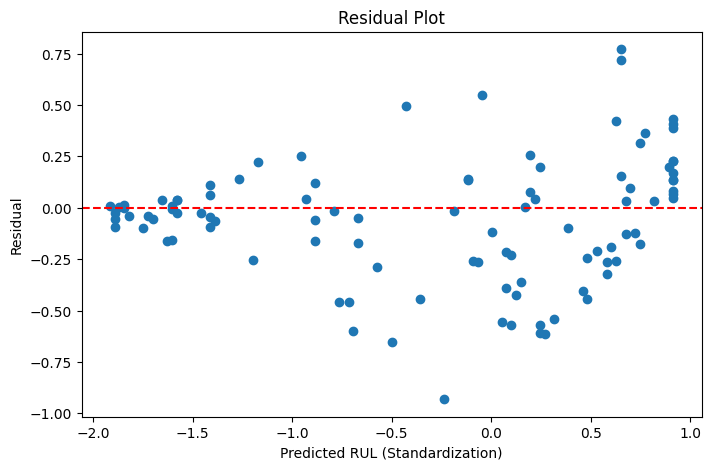

In [30]:
residuals = y_test_scaled - y_test_pred_scaled

plt.figure(figsize=(8,5))
plt.scatter(y_test_scaled, residuals)
plt.axhline(0, linestyle='--',color='r')
plt.xlabel("Predicted RUL (Standardization)")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

### Observations

- The actual-vs-predicted scatter (standardized scale) clusters around the diagonal reference line, with the expected fan-out at the extremes - very low and very high RUL are inherently harder to pin down exactly.
- The residual plot shows no strong funnel or curved pattern, suggesting the model's errors are reasonably homoscedastic across the predicted RUL range rather than systematically worse for near-failure or healthy engines.


---
## 4. Binary Classification — Imminent Failure (≤ 30 Cycles)

An exact RUL number is useful, but a maintenance team often just needs a clear trigger: *"does this engine need attention soon?"* This section reframes the problem as binary classification - **will the engine fail within the next 30 cycles?** - which is easier to act on and lets us bring in classification metrics (precision/recall, ROC-AUC) that speak directly to missed-failure risk.


In [31]:
train['failure_30'] = (train['RUL_capped'] <= 30).astype(int)

### Engine-Level Train/Validation Split

The split is done on `engine_id`, not on individual rows. Splitting randomly by row would put cycles from the *same* engine trajectory into both train and validation, leaking near-identical information across the split and producing an overly optimistic validation score. Splitting whole engines avoids that leakage.


In [32]:
from sklearn.model_selection import train_test_split

engine_ids = train['engine_id'].unique()

train_engines, val_engines = train_test_split(engine_ids, test_size=0.2, random_state=42)
train_df = train[train['engine_id'].isin(train_engines)]
val_df = train[train['engine_id'].isin(val_engines)]

print(train_df['failure_30'].value_counts(normalize=True))
print(val_df['failure_30'].value_counts(normalize=True))

failure_30
0    0.850251
1    0.149749
Name: proportion, dtype: float64
failure_30
0    0.847666
1    0.152334
Name: proportion, dtype: float64


The ~85% / 15% healthy/failing-soon class balance is preserved almost exactly between the train (85.0% / 15.0%) and validation (84.8% / 15.2%) splits, confirming the split is representative and that **class imbalance** - not a shift in the underlying distribution - is the main challenge for the classifier.


### Feature Preparation

Reuses the same engineered feature set as the regression models (minus the RUL-derived and label columns, to avoid leaking the answer into the inputs) and converts the train/validation engine subsets into NumPy arrays.


In [33]:
CLF_FEATURES = [c for c in train.columns if c not in {'engine_id','cycle','RUL_capped','cycle_count_scaled','RUL_capped_scaled','failure_30'}]

X_train = train_df.drop(columns=['failure_30'])
X_train = train_df[CLF_FEATURES].values
y_train = train_df['failure_30'].values

X_val = val_df.drop(columns=['failure_30'])
X_val = val_df[CLF_FEATURES].values
y_val = val_df['failure_30'].values

### XGBoost Classifier

Key hyperparameter choices:
- **`scale_pos_weight`**: set to the train-set ratio of healthy-to-failing rows, which up-weights the minority ("failing soon") class during training to counter the ~85/15 imbalance.
- **`n_estimators=300`, `max_depth=6`, `learning_rate=0.05`**: a moderately deep, slow-learning ensemble.
- **`subsample=0.8`, `colsample_bytree=0.8`**: row/column subsampling for regularization, reducing the risk of the 300 trees overfitting to training-set idiosyncrasies.


In [34]:
scale_pos_weight = (train['failure_30'].value_counts()[0] / train['failure_30'].value_counts()[1])

clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
)

clf.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [35]:
y_train_pred = clf.predict(X_train)
y_val_pred = clf.predict(X_val)

In [36]:
print("Training Data")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred)}")
print(f'Precision: {precision_score(y_train, y_train_pred)}')
print(f'Recall: {recall_score(y_train, y_train_pred)}')

print()

print("Validation Data")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred)}")
print(f'Precision: {precision_score(y_val, y_val_pred)}')
print(f'Recall: {recall_score(y_val, y_val_pred)}')

Training Data
Accuracy: 1.0
Precision: 1.0
Recall: 1.0

Validation Data
Accuracy: 0.975921375921376
Precision: 0.9264705882352942
Recall: 0.9145161290322581


In [37]:
y_prob = clf.predict_proba(X_val)[:,1]

roc_auc = roc_auc_score(y_val, y_prob)

print("ROC AUC:", roc_auc)

print(confusion_matrix(y_val,y_val_pred))

ROC AUC: 0.9963450210378682
[[3405   45]
 [  53  567]]


### Key Findings — Failure Classifier

| Split | Accuracy | Precision | Recall |
|---|---|---|---|
| Train | 1.000 | 1.000 | 1.000 |
| Validation | 0.976 | 0.926 | 0.915 |

- **Perfect training scores are a red flag**, not a success: 300 trees at depth 6 are expressive enough to memorize the training engines outright. The validation numbers are what actually matter here.
- On validation, the classifier reaches **97.6% accuracy** with **92.6% precision** and **91.5% recall** on the minority "failing soon" class, and a **ROC-AUC of 0.996** - strong separability between the two classes despite the imbalance.
- The confusion matrix (`[[3405, 45], [53, 567]]`) shows 53 missed failures (false negatives) against 567 correctly caught ones - in a maintenance context, these are the cases that matter most, since a missed failure carries far higher cost than a false alarm.


---
## 5. Cross-Checking the LSTM and the Classifier

Two independently trained models now exist that both speak to "is this engine close to failing?" - the LSTM via its continuous RUL prediction (thresholded at ≤ 30 cycles) and the XGBoost classifier directly. Comparing their agreement on the test engines is a useful sanity check: if two models trained on different representations of the same data agree, that's evidence the signal is real rather than an artifact of one particular modeling approach.

In [38]:
X_test_lstm = test[LSTM_FEATURES]
X_test_xgb = test[CLF_FEATURES]

y_test_lstm = test_output['RUL_capped'].values
y_test_xgb = np.array((test_output['RUL_capped'] <= 30).astype(int))

Builds matched test inputs for both models from the same set of test engines: a 30-cycle window per engine for the LSTM, and the single last-row feature vector per engine for the XGBoost classifier. Engines with fewer than 30 recorded cycles are skipped, since the LSTM has no valid window to draw from.


In [39]:
def create_combined_model_test_sequences(df, seq_len, lstm_features, xgb_features):
    X_test_lstm = []
    X_test_xgb = []

    for eid in df['engine_id'].unique():
        engine = df[df['engine_id'] == eid]

        if len(engine) < seq_len:
            continue

        X_test_lstm.append(engine[lstm_features].values[-seq_len:])
        X_test_xgb.append(engine[xgb_features].values[-1])

    return (np.array(X_test_lstm, dtype=np.float32),np.array(X_test_xgb, dtype=np.float32))

In [40]:
X_test_lstm, X_test_xgb = create_combined_model_test_sequences(test, SEQ_LEN, LSTM_FEATURES, CLF_FEATURES)

Generates RUL predictions from the LSTM (inverse-transformed back to raw cycles) and failure predictions from the XGBoost classifier on the matched test engines, then derives a comparable binary "failing soon" flag from the LSTM's RUL output using the same ≤ 30-cycle threshold used to train the classifier.


In [41]:
y_test_pred_lstm_scaled = model_predictions(model, X_test_lstm)
y_test_pred_lstm = rul_scaler.inverse_transform(y_test_pred_lstm_scaled.reshape(-1, 1))
y_test_pred_xgb = clf.predict(X_test_xgb)

In [42]:
lstm_failure_pred = (y_test_pred_lstm <= 30).astype(int).flatten()
xgb_failure_pred = clf.predict(X_test_xgb)

In [43]:
np.mean(lstm_failure_pred == xgb_failure_pred)

np.float64(0.97)

### Key Findings

The LSTM-derived failure flag and the XGBoost classifier's direct prediction **agree on 97% of test engines**. Given that one model reasons over a 30-cycle sensor trajectory and the other over a single engineered snapshot, this level of agreement is a strong, model-agnostic signal that the underlying degradation pattern is being picked up consistently - not an artifact of either model's particular inductive bias.


---
## 6. Summary

Aircraft Engine RUL Modelling - What we built
Four models were trained on the engineered NASA C-MAPSS FD001 feature set, covering both a continuous RUL regression task and an actionable binary failure-classification task.
---

#### 1. How did the Regression models compare?

| Model | R² | MAE (cycles) |
|---|---|---|
| Random Forest | 0.887 | 10.05 |
| XGBoost (default) | 0.870 | 10.63 |
| **LSTM** | **0.900** | **9.40** |

The LSTM, which is the only model that sees a *trajectory* of cycles rather than a single snapshot, came out ahead on both metrics - consistent with the EDA finding that degradation is a temporal, accelerating process rather than a static state.

---

#### 2. How well does the failure classifier performs?

The XGBoost classifier flagging "failure within 30 cycles" reached **97.6% validation accuracy**, **92.6% precision**, **91.5% recall**, and a **0.996 ROC-AUC** - strong enough to support real maintenance-trigger decisions, though the 53 missed failures in validation are worth monitoring in any production rollout.

---

### 3. What did the cross-model check confirm?

The LSTM's RUL-derived failure flag and the standalone classifier agreed on **97%** of test engines, adding confidence that both models are picking up the same underlying degradation signal rather than overfitting to incidental patterns in their respective feature representations.
